# Target: P (amyloid beta == postive | New patient ) pipeline

***

### KR Font

In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스(-) 기호 깨지는 것 방지

## Data Load

In [2]:
import numpy as np
import pandas as pd
path = "../../Data/Preprocessed/scstBiomark_vaccine_naive_889_no_biomarker_filter_deidentified_merged.xlsx"
df_composite = pd.read_excel(path, sheet_name='composite_scores')

In [3]:
df_composite['1st_cognitive_status'].value_counts()

1st_cognitive_status
MCI         403
Dementia    272
SCD         214
Name: count, dtype: int64

### Fill NA

In [5]:
# df 전체 컬럼에서 NaN 개수 확인
na_counts = df_composite.isna().sum()
print(na_counts[na_counts > 0])

졸업여부    4
dtype: int64


In [6]:
na_fill_cols = ['place_recognition_z_score', 'cst_memory_z_score', 'cst_total_z_score']

for col in na_fill_cols:
    n_na = df_composite[col].isna().sum()
    mean_val = df_composite[col].mean()
    df_composite[col] = df_composite[col].fillna(mean_val)
    print(f"{col}: NaN {n_na}개 -> 평균값 {mean_val:.4f}로 채움")

place_recognition_z_score: NaN 0개 -> 평균값 -0.6878로 채움
cst_memory_z_score: NaN 0개 -> 평균값 -1.7328로 채움
cst_total_z_score: NaN 0개 -> 평균값 -0.8735로 채움


***

## Experiments

In [7]:
target_folder = "amyloid_beta_prob_pipeline"

In [8]:
from pathlib import Path
import sys

try:
    # .py 파이썬 스크립트로 실행될 때
    current_dir = Path(__file__).resolve().parent
except NameError:
    # 주피터 노트북(.ipynb) 환경에서 실행될 때
    current_dir = Path.cwd()

amyloid_dir = (current_dir.parent / target_folder).resolve()
sys.path.append(str(amyloid_dir))

import data_prep, modeling, stats_tests, reporting
import run_experiments as run
import config as cfg

print(cfg.__file__)                          # 올바른 모듈인지 확인

/work/Project/amyloid_beta_prob_pipeline/config.py


### preparing

In [9]:
df, covariate_column_map = data_prep.preprocess(df_composite)

[preprocess] n=889, 양성=362 (40.7%), 음성=527
[preprocess] 모델 투입 가능 컬럼 24개, 결측 없음
[preprocess] covariate_column_map = {'AGE': ['AGE'], 'education_year': ['education_year'], 'APOE': ['APOE_e4_carrier'], 'sex': ['sex_여성'], '1st_cognitive_status': ['is_MCI', 'is_Dementia']}


### training

In [10]:
summary_df, detail_results = run.run_all_experiments(
    df, covariate_column_map,
    target_folder=target_folder,
    result_folder="889_amyloid_beta_prob_pipeline",
)


Group: All  (n=889, 양성=362, 음성=527)

--- M1_All (n_features=18, covariates=[]) ---
    EPV = 362/18 = 20.1

--- M2_All (n_features=21, covariates=['sex', 'AGE', 'education_year']) ---
    EPV = 362/21 = 17.2

--- M3_All (n_features=23, covariates=['sex', 'AGE', 'education_year', '1st_cognitive_status']) ---
    EPV = 362/23 = 15.7

--- M4_All (n_features=24, covariates=['sex', 'AGE', 'education_year', '1st_cognitive_status', 'APOE']) ---
    EPV = 362/24 = 15.1

Group: SCD_MCI  (n=617, 양성=177, 음성=440)

--- M1_SCD_MCI (n_features=18, covariates=[]) ---
    EPV = 177/18 = 9.8  <-- 낮음(권장 10 이상), 계수 해석에 주의

--- M2_SCD_MCI (n_features=21, covariates=['sex', 'AGE', 'education_year']) ---
    EPV = 177/21 = 8.4  <-- 낮음(권장 10 이상), 계수 해석에 주의

--- M3_SCD_MCI (n_features=23, covariates=['sex', 'AGE', 'education_year', '1st_cognitive_status']) ---
    EPV = 177/23 = 7.7  <-- 낮음(권장 10 이상), 계수 해석에 주의
  [M3_SCD_MCI] 상수 컬럼 제외 (이 subgroup에서 값이 하나뿐): ['is_Dementia']

--- M4_SCD_MCI (n_features=24, cova

***

## **Report**


######################################################################
# Group: All
######################################################################

[All] M1_All  (n=889, events=362, features=18, EPV=20.1)
=== Fold별 F1 / AUC (out-of-fold) ===
 fold       f1      auc
    1 0.685714 0.770571
    2 0.695652 0.790225
    3 0.689655 0.776517
    4 0.671429 0.796608
    5 0.734694 0.819974

F1  mean ± std : 0.695 ± 0.024
AUC mean ± std : 0.791 ± 0.019

=== Pooled OOF classification_report (threshold=0.463) ===
              precision    recall  f1-score   support

           0      0.787     0.808     0.798       527
           1      0.710     0.682     0.696       362

    accuracy                          0.757       889
   macro avg      0.749     0.745     0.747       889
weighted avg      0.756     0.757     0.756       889



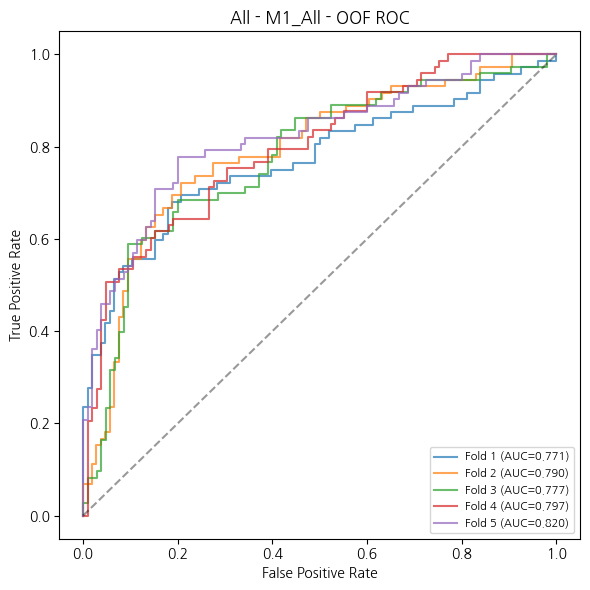


=== All/M1_All Odds Ratio (최종 refit 모델, n=18 features) ===
mark                                feature  β=log(OR)         OR (95% CI)      p
   ★            delayed_free_recall_z_score     -0.351 0.704 (0.597–0.831) <0.001
   ★                       cowat_di_z_score      0.226 1.254 (1.076–1.461)  0.004
   ★                visual_backward_z_score     -0.217 0.805 (0.667–0.972)  0.024
                             naming_z_score      0.188 1.207 (1.036–1.406)  0.016
      immediate_free_recall_trial_2_z_score     -0.187 0.830 (0.670–1.027)  0.087
            trailmaking_part_b_time_z_score     -0.177 0.838 (0.690–1.018)  0.074
                       cowat_fruits_z_score      0.147 1.159 (0.979–1.372)  0.087
                       block_design_z_score     -0.137 0.872 (0.719–1.059)  0.167
             time_orientation_total_z_score     -0.102 0.903 (0.848–0.963)  0.002
     word_recognition_true_positive_z_score     -0.080 0.923 (0.844–1.010)  0.080
                  place_recognition_z_

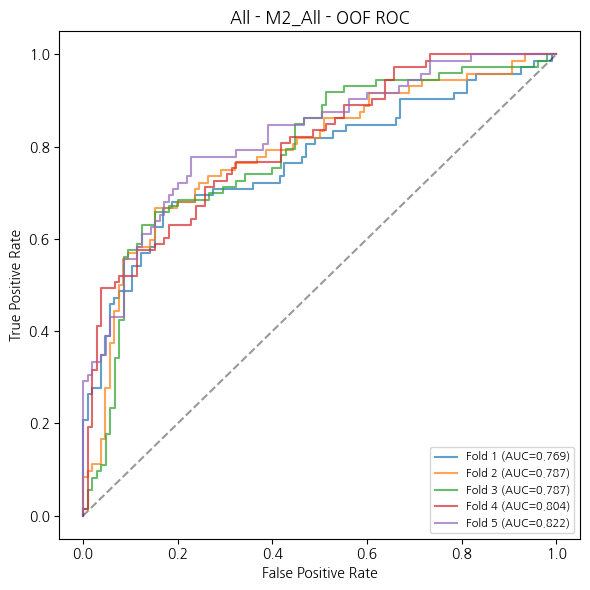


=== All/M2_All Odds Ratio (최종 refit 모델, n=21 features) ===
mark                                feature  β=log(OR)         OR (95% CI)      p
   ★                                 sex_여성      0.399 1.490 (1.042–2.130)  0.029
   ★            delayed_free_recall_z_score     -0.344 0.709 (0.600–0.838) <0.001
   ★                visual_backward_z_score     -0.241 0.786 (0.649–0.952)  0.014
                           cowat_di_z_score      0.237 1.267 (1.083–1.482)  0.003
      immediate_free_recall_trial_2_z_score     -0.184 0.832 (0.670–1.032)  0.095
                             naming_z_score      0.184 1.202 (1.030–1.402)  0.020
            trailmaking_part_b_time_z_score     -0.176 0.839 (0.688–1.023)  0.083
                       cowat_fruits_z_score      0.157 1.170 (0.987–1.387)  0.070
                       block_design_z_score     -0.138 0.871 (0.717–1.058)  0.165
             time_orientation_total_z_score     -0.103 0.902 (0.844–0.964)  0.002
     word_recognition_true_positive_z_

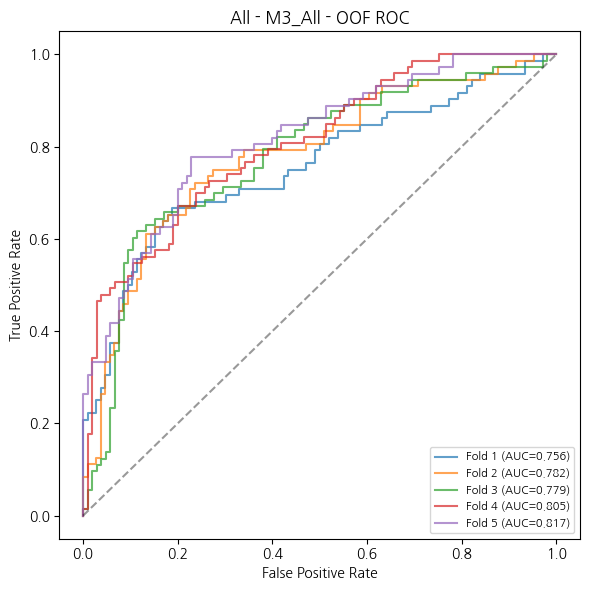


=== All/M3_All Odds Ratio (최종 refit 모델, n=23 features) ===
mark                                feature  β=log(OR)         OR (95% CI)      p
                                is_Dementia      0.547 1.728 (0.872–3.423)  0.117
   ★                                 sex_여성      0.404 1.497 (1.046–2.143)  0.027
                                     is_MCI      0.341 1.406 (0.850–2.327)  0.184
   ★            delayed_free_recall_z_score     -0.315 0.730 (0.616–0.866) <0.001
   ★                       cowat_di_z_score      0.251 1.285 (1.097–1.505)  0.002
                    visual_backward_z_score     -0.237 0.789 (0.651–0.956)  0.015
                             naming_z_score      0.192 1.212 (1.038–1.414)  0.015
      immediate_free_recall_trial_2_z_score     -0.176 0.839 (0.675–1.042)  0.112
                       cowat_fruits_z_score      0.164 1.179 (0.994–1.398)  0.059
            trailmaking_part_b_time_z_score     -0.161 0.851 (0.698–1.039)  0.113
                       block_design_z_

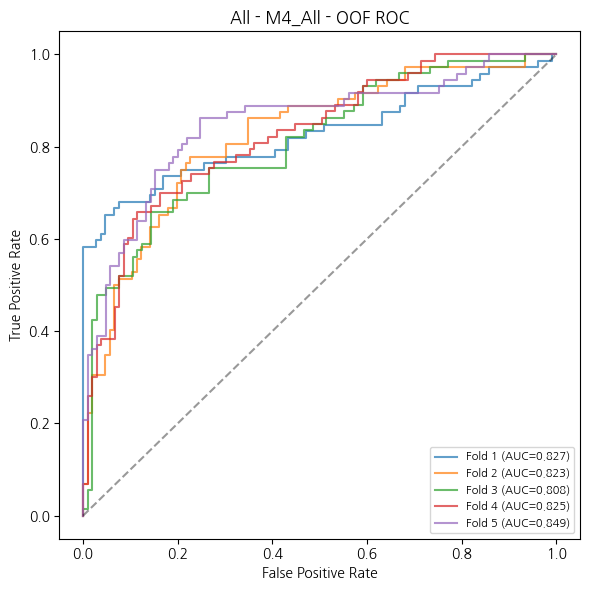


=== All/M4_All Odds Ratio (최종 refit 모델, n=24 features) ===
mark                                feature  β=log(OR)         OR (95% CI)      p
   ★                        APOE_e4_carrier      1.614 5.020 (3.510–7.181) <0.001
   ★                                 sex_여성      0.389 1.475 (1.006–2.162)  0.046
   ★            delayed_free_recall_z_score     -0.325 0.722 (0.602–0.867) <0.001
                                is_Dementia      0.299 1.348 (0.652–2.790)  0.420
                                     is_MCI      0.242 1.274 (0.751–2.161)  0.370
                           cowat_di_z_score      0.212 1.236 (1.043–1.465)  0.015
      immediate_free_recall_trial_2_z_score     -0.202 0.817 (0.650–1.028)  0.085
                    visual_backward_z_score     -0.194 0.823 (0.671–1.010)  0.062
            trailmaking_part_b_time_z_score     -0.171 0.843 (0.681–1.043)  0.116
                       cowat_fruits_z_score      0.129 1.138 (0.949–1.363)  0.162
                             naming_z_

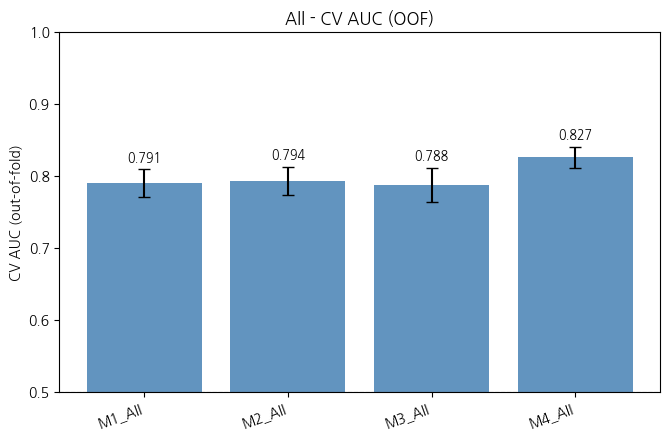


--- All 인접 Model DeLong 비교 (pooled OOF) ---
Group   from     to  auc_from  auc_to  auc_diff  p_value
  All M1_All M2_All    0.7909  0.7942    0.0033   0.2859
  All M2_All M3_All    0.7942  0.7885   -0.0057   0.0109
  All M3_All M4_All    0.7885  0.8250    0.0365   0.0000

######################################################################
# Group: SCD_MCI
######################################################################

[SCD_MCI] M1_SCD_MCI  (n=617, events=177, features=18, EPV=9.8)
=== Fold별 F1 / AUC (out-of-fold) ===
 fold       f1      auc
    1 0.623377 0.750316
    2 0.518519 0.679609
    3 0.481928 0.657143
    4 0.567901 0.728896
    5 0.432432 0.649351

F1  mean ± std : 0.525 ± 0.074
AUC mean ± std : 0.693 ± 0.045

=== Pooled OOF classification_report (threshold=0.311) ===
              precision    recall  f1-score   support

           0      0.817     0.739     0.776       440
           1      0.475     0.588     0.525       177

    accuracy                      

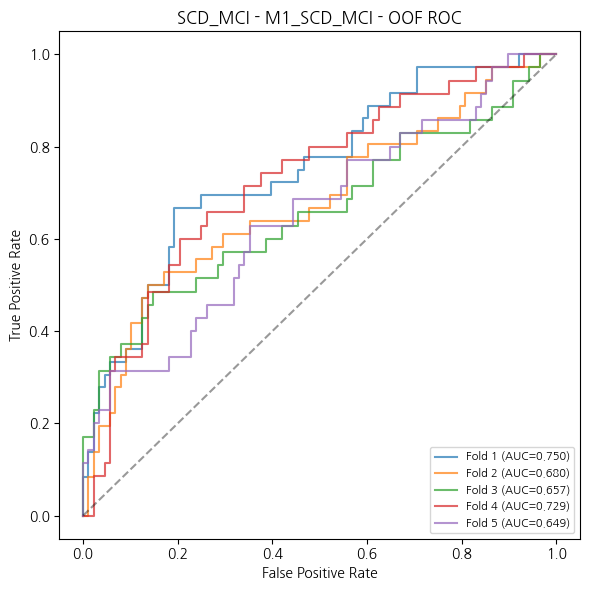


=== SCD_MCI/M1_SCD_MCI Odds Ratio (최종 refit 모델, n=18 features) ===
mark                                feature  β=log(OR)         OR (95% CI)      p
   ★            delayed_free_recall_z_score     -0.337 0.714 (0.588–0.867) <0.001
      immediate_free_recall_trial_2_z_score     -0.237 0.789 (0.611–1.019)  0.069
                    visual_backward_z_score     -0.218 0.804 (0.639–1.012)  0.063
                           cowat_di_z_score      0.154 1.166 (0.981–1.386)  0.081
                       cowat_fruits_z_score      0.123 1.131 (0.928–1.379)  0.223
                             naming_z_score      0.117 1.124 (0.931–1.357)  0.222
                     visual_forward_z_score     -0.105 0.900 (0.705–1.149)  0.398
     word_recognition_true_negative_z_score     -0.097 0.908 (0.821–1.003)  0.057
      immediate_free_recall_trial_3_z_score      0.085 1.088 (0.852–1.391)  0.499
                       block_design_z_score     -0.071 0.931 (0.743–1.167)  0.537
                  place_recogn

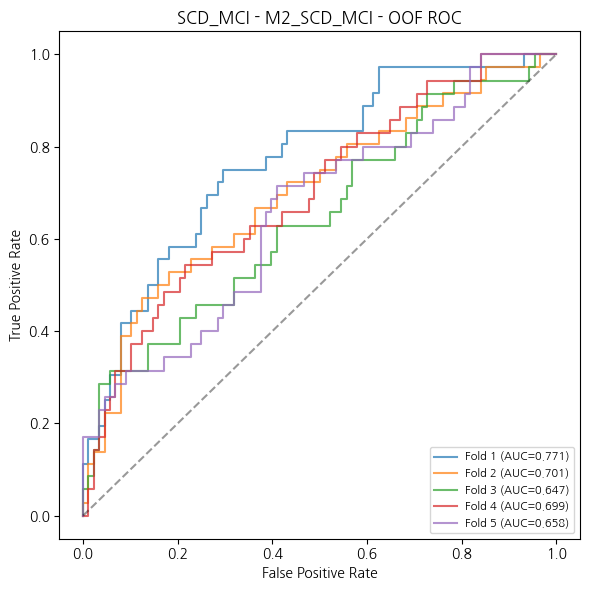


=== SCD_MCI/M2_SCD_MCI Odds Ratio (최종 refit 모델, n=21 features) ===
mark                                feature  β=log(OR)         OR (95% CI)     p
   ★                                 sex_여성      0.519 1.680 (1.087–2.596) 0.020
   ★            delayed_free_recall_z_score     -0.322 0.724 (0.595–0.883) 0.001
   ★                visual_backward_z_score     -0.243 0.785 (0.621–0.992) 0.042
      immediate_free_recall_trial_2_z_score     -0.237 0.789 (0.609–1.021) 0.072
                           cowat_di_z_score      0.162 1.176 (0.985–1.404) 0.073
                       cowat_fruits_z_score      0.130 1.139 (0.932–1.392) 0.202
                             naming_z_score      0.118 1.125 (0.928–1.363) 0.231
      immediate_free_recall_trial_3_z_score      0.111 1.117 (0.871–1.433) 0.382
     word_recognition_true_negative_z_score     -0.103 0.902 (0.814–1.000) 0.050
                     visual_forward_z_score     -0.088 0.916 (0.716–1.171) 0.483
                  place_recognition_z_sco

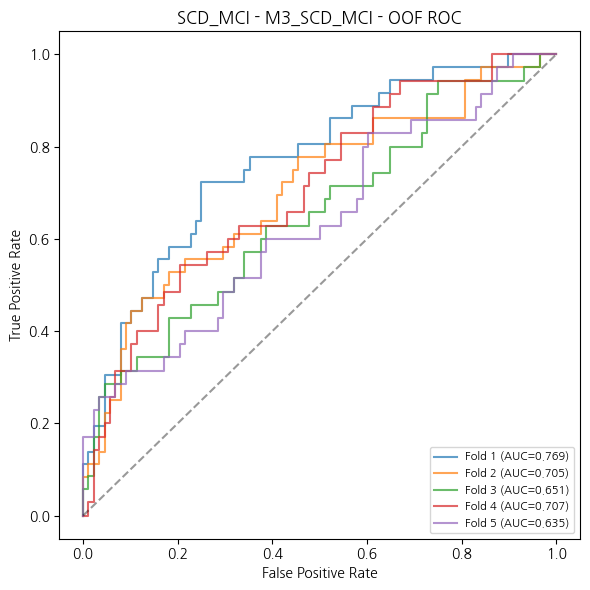


=== SCD_MCI/M3_SCD_MCI Odds Ratio (최종 refit 모델, n=22 features) ===
mark                                feature  β=log(OR)         OR (95% CI)     p
   ★                                 sex_여성      0.526 1.693 (1.095–2.616) 0.018
                                     is_MCI      0.333 1.395 (0.829–2.347) 0.210
   ★            delayed_free_recall_z_score     -0.304 0.738 (0.605–0.900) 0.003
   ★                visual_backward_z_score     -0.239 0.787 (0.623–0.996) 0.046
      immediate_free_recall_trial_2_z_score     -0.233 0.792 (0.612–1.025) 0.077
                           cowat_di_z_score      0.174 1.190 (0.995–1.422) 0.056
                       cowat_fruits_z_score      0.140 1.151 (0.941–1.407) 0.170
                             naming_z_score      0.131 1.140 (0.940–1.382) 0.184
      immediate_free_recall_trial_3_z_score      0.104 1.110 (0.866–1.423) 0.410
     word_recognition_true_negative_z_score     -0.099 0.906 (0.818–1.003) 0.057
                     visual_forward_z_sco

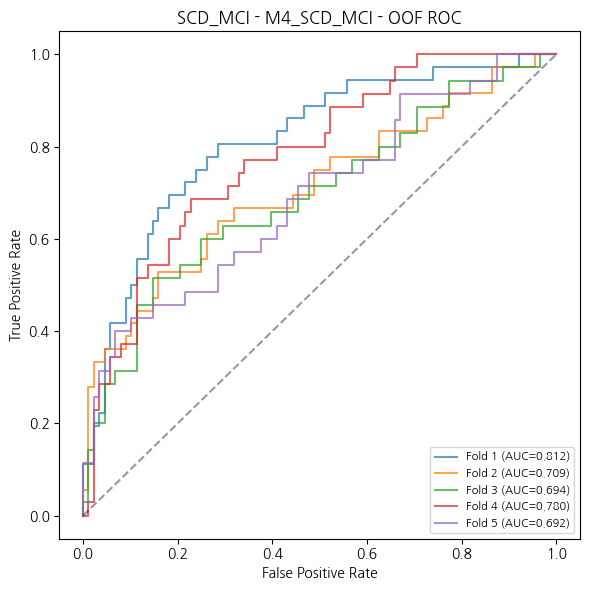


=== SCD_MCI/M4_SCD_MCI Odds Ratio (최종 refit 모델, n=23 features) ===
mark                                feature  β=log(OR)         OR (95% CI)      p
   ★                        APOE_e4_carrier      1.283 3.607 (2.355–5.525) <0.001
   ★                                 sex_여성      0.491 1.633 (1.037–2.572)  0.034
   ★            delayed_free_recall_z_score     -0.318 0.728 (0.591–0.897)  0.003
      immediate_free_recall_trial_2_z_score     -0.288 0.750 (0.574–0.981)  0.036
                                     is_MCI      0.279 1.322 (0.772–2.264)  0.309
                    visual_backward_z_score     -0.176 0.839 (0.657–1.071)  0.158
                           cowat_di_z_score      0.158 1.171 (0.971–1.412)  0.099
                     visual_forward_z_score     -0.124 0.883 (0.685–1.139)  0.337
      immediate_free_recall_trial_3_z_score      0.124 1.132 (0.873–1.469)  0.349
                             naming_z_score      0.104 1.110 (0.909–1.355)  0.307
                       cowat_f

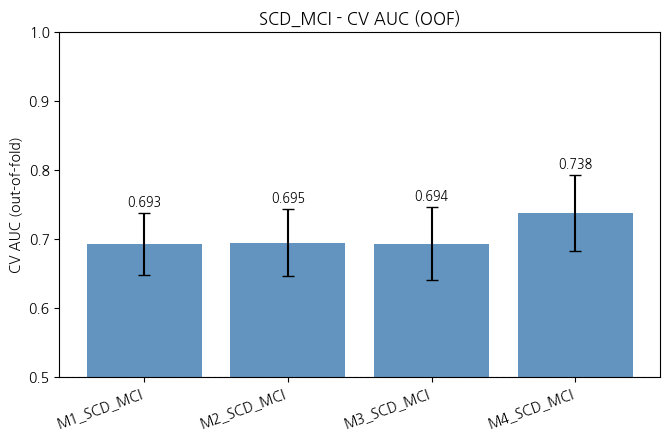


--- SCD_MCI 인접 Model DeLong 비교 (pooled OOF) ---
  Group       from         to  auc_from  auc_to  auc_diff  p_value
SCD_MCI M1_SCD_MCI M2_SCD_MCI    0.6920  0.6933    0.0014   0.8592
SCD_MCI M2_SCD_MCI M3_SCD_MCI    0.6933  0.6933   -0.0001   0.9879
SCD_MCI M3_SCD_MCI M4_SCD_MCI    0.6933  0.7368    0.0435   0.0012

######################################################################
# Group: Dementia
######################################################################

[Dementia] M1_Dementia  (n=272, events=185, features=18, EPV=4.8)
=== Fold별 F1 / AUC (out-of-fold) ===
 fold       f1      auc
    1 0.812500 0.882883
    2 0.666667 0.657658
    3 0.698413 0.756757
    4 0.738462 0.655008
    5 0.687500 0.709062

F1  mean ± std : 0.721 ± 0.058
AUC mean ± std : 0.732 ± 0.094

=== Pooled OOF classification_report (threshold=0.737) ===
              precision    recall  f1-score   support

           0      0.489     0.759     0.595        87
           1      0.847     0.627     0.72

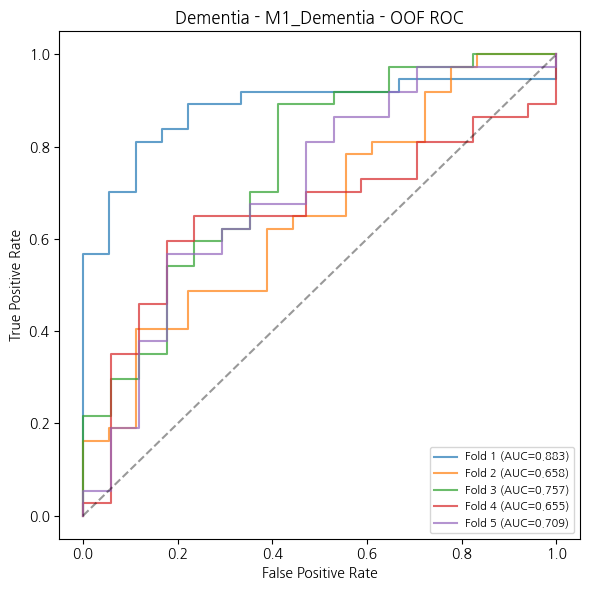


=== Dementia/M1_Dementia Odds Ratio (최종 refit 모델, n=18 features) ===
mark                                feature  β=log(OR)         OR (95% CI)     p
   ★                       cowat_di_z_score      0.486 1.626 (1.139–2.321) 0.007
            trailmaking_part_b_time_z_score     -0.451 0.637 (0.401–1.012) 0.056
   ★            delayed_free_recall_z_score     -0.445 0.641 (0.411–0.999) 0.049
                             naming_z_score      0.273 1.314 (0.990–1.743) 0.058
                       block_design_z_score     -0.250 0.779 (0.506–1.200) 0.258
                  place_recognition_z_score     -0.194 0.824 (0.419–1.622) 0.575
                       cowat_fruits_z_score      0.176 1.193 (0.852–1.669) 0.304
            trailmaking_part_a_time_z_score      0.171 1.187 (0.802–1.757) 0.392
                    visual_backward_z_score     -0.161 0.852 (0.587–1.236) 0.399
   ★ word_recognition_true_positive_z_score     -0.138 0.871 (0.767–0.989) 0.033
             time_orientation_total_z_s

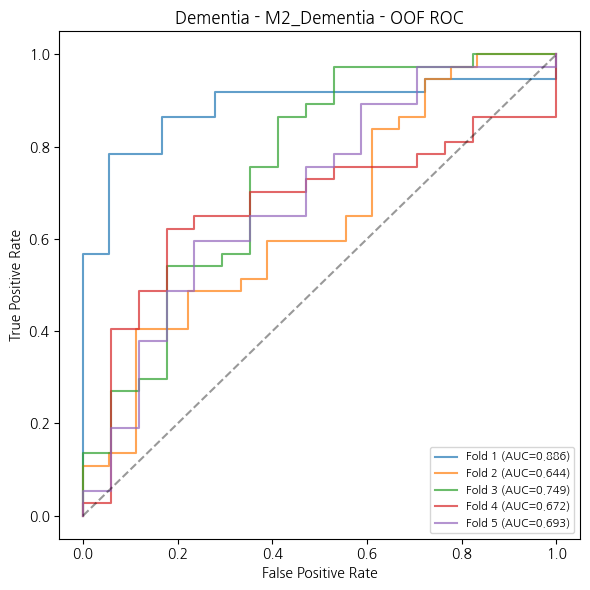


=== Dementia/M2_Dementia Odds Ratio (최종 refit 모델, n=21 features) ===
mark                                feature  β=log(OR)         OR (95% CI)     p
   ★            delayed_free_recall_z_score     -0.510 0.600 (0.375–0.961) 0.033
   ★                       cowat_di_z_score      0.501 1.651 (1.146–2.378) 0.007
            trailmaking_part_b_time_z_score     -0.464 0.629 (0.395–1.001) 0.050
                             naming_z_score      0.270 1.310 (0.982–1.747) 0.066
                       block_design_z_score     -0.253 0.776 (0.501–1.203) 0.258
                  place_recognition_z_score     -0.236 0.790 (0.386–1.613) 0.517
                                     sex_여성      0.176 1.192 (0.580–2.449) 0.632
                       cowat_fruits_z_score      0.166 1.181 (0.838–1.666) 0.343
                    visual_backward_z_score     -0.155 0.857 (0.588–1.249) 0.421
   ★ word_recognition_true_positive_z_score     -0.139 0.870 (0.766–0.988) 0.032
             time_orientation_total_z_s

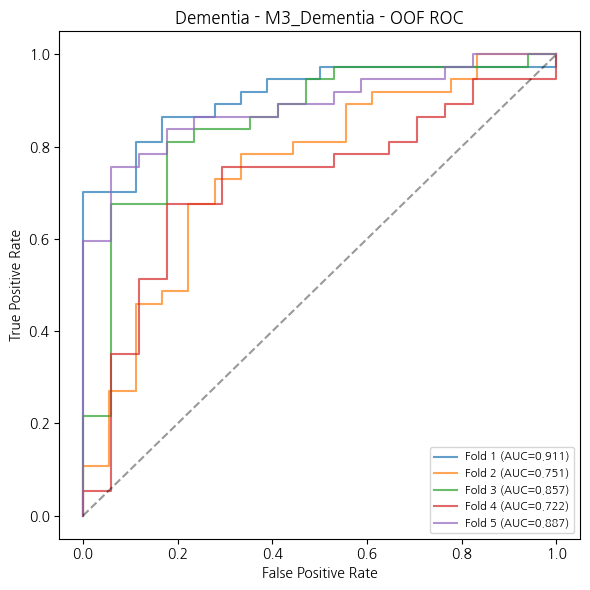


=== Dementia/M3_Dementia Odds Ratio (최종 refit 모델, n=22 features) ===
mark                                feature  β=log(OR)           OR (95% CI)      p
   ★                        APOE_e4_carrier      2.514 12.355 (5.638–27.076) <0.001
                delayed_free_recall_z_score     -0.504   0.604 (0.359–1.017)  0.058
                           cowat_di_z_score      0.351   1.420 (0.940–2.145)  0.095
            trailmaking_part_b_time_z_score     -0.320   0.726 (0.434–1.214)  0.222
                                     sex_여성      0.304   1.355 (0.584–3.142)  0.479
                       block_design_z_score     -0.254   0.776 (0.471–1.276)  0.317
                    visual_backward_z_score     -0.231   0.794 (0.510–1.234)  0.305
      immediate_free_recall_trial_3_z_score     -0.203   0.817 (0.532–1.253)  0.354
                       cowat_fruits_z_score      0.191   1.211 (0.818–1.793)  0.340
                  place_recognition_z_score     -0.171   0.843 (0.380–1.869)  0.675
      

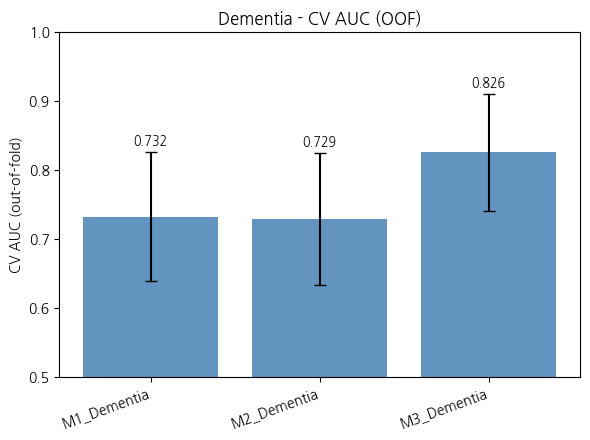


--- Dementia 인접 Model DeLong 비교 (pooled OOF) ---
   Group        from          to  auc_from  auc_to  auc_diff  p_value
Dementia M1_Dementia M2_Dementia    0.7361  0.7272   -0.0089   0.1757
Dementia M2_Dementia M3_Dementia    0.7272  0.8201    0.0928   0.0003


In [11]:
run.print_full_report(detail_results)

***

## **Export**

In [13]:
result_dir = amyloid_dir / "results" / "889_amyloid_beta_prob_pipeline"

run.export_all_models_json(
    detail_results, covariate_column_map,
    result_dir / "models.json",
)

run.make_golden_set(
    detail_results, df, covariate_column_map, "M4_SCD_MCI",
    result_dir / "golden_M4_SCD_MCI.csv",
)

JSON 저장 완료: /work/Project/amyloid_beta_prob_pipeline/results/889_amyloid_beta_prob_pipeline/models.json  (모델 11개)
golden set 저장 완료: /work/Project/amyloid_beta_prob_pipeline/results/889_amyloid_beta_prob_pipeline/golden_M4_SCD_MCI.csv  (n=20)
  -> HTML에 같은 값을 넣고 python_prob과 소수점 6자리까지 일치하는지 확인하세요.


,model_name,visual_forward_z_score,visual_backward_z_score,cowat_fruits_z_score,cowat_di_z_score,naming_z_score,block_design_z_score,time_orientation_total_z_score,immediate_free_recall_trial_1_z_score,immediate_free_recall_trial_2_z_score,...,trailmaking_part_a_time_z_score,trailmaking_part_a_error_z_score,trailmaking_part_b_time_z_score,trailmaking_part_b_error_z_score,sex_여성,AGE,education_year,is_MCI,APOE_e4_carrier,python_prob
57,M4_SCD_MCI,0.93,0.39,0.15,2.64,0.71,1.10,-1.53,-0.56,0.18,...,0.29,-0.01,1.32,0.55,0.0,80.0,16.0,0.0,0.0,0.212521
818,M4_SCD_MCI,0.58,0.22,-0.21,0.82,-2.03,-0.13,0.46,-0.24,-0.34,...,-1.14,0.44,-0.25,-0.83,0.0,70.0,12.0,1.0,0.0,0.102296
99,M4_SCD_MCI,0.92,1.83,-1.27,0.37,1.34,1.84,0.73,0.49,1.06,...,-0.47,1.09,-0.24,2.22,1.0,82.0,16.0,1.0,0.0,0.087097
374,M4_SCD_MCI,0.14,0.45,1.15,0.94,-0.26,0.47,0.39,-0.45,-1.31,...,1.77,0.23,1.64,-0.14,1.0,62.0,12.0,0.0,0.0,0.190492
130,M4_SCD_MCI,1.07,1.19,1.68,2.38,1.30,0.60,0.36,-0.58,-0.01,...,-0.18,0.02,2.81,0.08,1.0,62.0,16.0,0.0,0.0,0.165744
856,M4_SCD_MCI,-1.89,-2.35,0.05,-0.99,-1.58,-1.00,-3.87,-0.62,-1.52,...,-1.77,-0.64,-1.47,8.90,0.0,92.0,12.0,1.0,0.0,0.430319
331,M4_SCD_MCI,0.58,0.01,0.06,-1.45,0.24,0.56,0.53,0.60,-0.19,...,-1.16,-1.49,-0.54,-0.09,1.0,74.0,12.0,0.0,0.0,0.160090
430,M4_SCD_MCI,1.34,1.29,-0.19,1.95,-0.24,-1.24,0.61,-0.68,1.78,...,-0.02,0.50,2.02,0.59,1.0,78.0,12.0,0.0,0.0,0.059212
401,M4_SCD_MCI,-0.70,0.78,0.33,1.21,-0.19,0.09,0.19,-1.26,0.15,...,-1.30,-0.08,-1.12,-0.19,0.0,52.0,14.0,1.0,1.0,0.345096
577,M4_SCD_MCI,2.17,0.66,0.39,-0.44,-0.59,1.48,0.76,-1.08,-0.36,...,0.24,-0.27,0.62,0.33,1.0,91.0,12.0,1.0,0.0,0.278907
